# 1.Simple Linear Regression

MSE == >  71.67543021367283


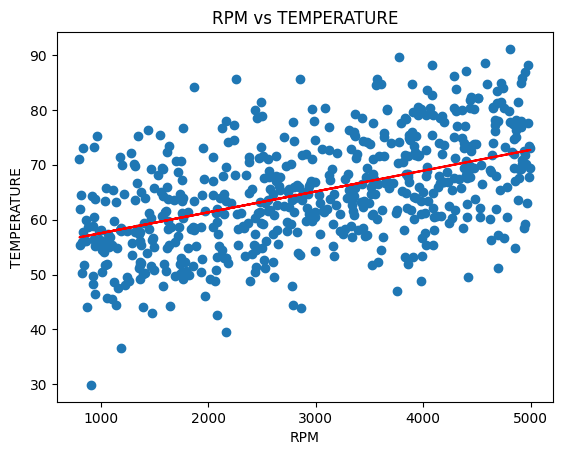

[54.01559951]
R2 score === > 0.27380323465589584


C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [110]:
import pandas as pd
from sklearn import linear_model
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = pd.read_csv("smart_factory_machinery_data.csv")
X = df[["RPM"]]
Y = df["Temperature"]


# plt.scatter(X,Y , marker  = "+" , color = "red")
# plt.xlabel("Humidity")
# plt.ylabel("Temperature")
# plt.show()

# print(df.head())

X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    train_size = 0.7,
    random_state= 42
)

model1 = linear_model.LinearRegression()
model1.fit(
    X_train,
    Y_train
)
Y_pred = model1.predict(X_test)

MSE = mean_squared_error(Y_test,Y_pred)
print("MSE == > ", MSE)

plt.scatter(X_test,Y_test)
plt.plot(X_test,Y_pred,color = "red")
plt.title("RPM vs TEMPERATURE")
plt.xlabel("RPM")
plt.ylabel("TEMPERATURE")
plt.show()

print(model1.predict([[70]]))

from sklearn.metrics import r2_score
r2_sc = r2_score(Y_test, Y_pred)
print("R2 score === >",r2_sc)

In [76]:
print(df.head())

    RPM  Vibration  Pressure  Humidity  Voltage  Current   Load  \
0  1660       5.17     88.80     66.87   240.90    42.59  51.93   
1  4572       0.61     32.04     83.55   216.75    45.21  31.48   
2  3892       4.68    113.85     34.72   242.87    42.05  72.09   
3  1266       4.54     38.12     49.85   240.77     9.64  60.90   
4  4244       4.53     82.28     44.90   233.87    15.24  16.97   

   Operating_Hours Machine_Mode Maintenance_Level Shift_Type  Temperature  \
0              937   High-Speed           Average    Morning        71.40   
1             9329     Standard              Poor    Evening        67.07   
2             5946   High-Speed           Average    Evening        84.69   
3             8563     Standard              Poor      Night        63.83   
4             2469          Eco           Average    Morning        60.22   

   Defective  
0          1  
1          1  
2          1  
3          1  
4          1  


# Multiple Feature Linear Regression

In [101]:
Machine_mode_dummy_df = pd.get_dummies(df['Machine_Mode'],prefix = "Machine_mode").astype(int)
Maintenance_dummy_df = pd.get_dummies(df["Maintenance_Level"],prefix = "Maintenance_level").astype(int)

# print(Machine_mode_dummy_df)
# print(Maintenance_dummy_df)

result_df = pd.concat([df,Machine_mode_dummy_df,Maintenance_dummy_df],axis = "columns")
result_df = result_df.drop(["Machine_Mode","Maintenance_Level","Shift_Type","Temperature"],axis = 'columns')
# print(result_df.head())


X = result_df[["RPM","Vibration","Pressure","Humidity","Voltage","Current","Load","Operating_Hours", "Defective", "Machine_mode_Eco","Machine_mode_High-Speed","Machine_mode_Standard","Maintenance_level_Average","Maintenance_level_Good","Maintenance_level_Poor"]]
Y = df["Temperature"]

X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    train_size = 0.7,
    random_state = 42
)

model = linear_model.LinearRegression()
model.fit(
    X_train,
    Y_train
)
Y_pred = model.predict(X_test)
MSE = mean_squared_error(Y_test,Y_pred)
print("MSE ==== > ",MSE)
r2 = r2_score(Y_test,Y_pred)
print("R2 === >", r2)


MSE ==== >  5.328991082328759
R2 === > 0.9460080522014572


# SAVE THE MODEL USING PICKLE AND JOBLIB

# Using Pickle

In [104]:
from pandas.io import pickle
import pickle

with open("Simple_model","wb") as file:
    pickle.dump(model1,file)
with open("Simple_model","rb") as file:
    simple_model = pickle.load(file)
simple_model.predict([[70]])

C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([54.01559951])

# Using Joblib

In [ ]:
import joblib

joblib.dump(model,"Multi_feature_model")
model = joblib.load("Multi_feature_model")
